# Energy Prediction Model for House Energy Consumption Optimization

In [1]:
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/DBA/household_power_consumption.csv")
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0


In [6]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [7]:
df.tail()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0
2075258,26/11/2010,21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


In [9]:
df.shape

(2075259, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [10]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,25979


In [11]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [12]:
df['Global_active_power'] = df['Global_active_power'].replace('?', np.nan).astype(float)
df['Global_reactive_power'] = df['Global_reactive_power'].replace('?', np.nan).astype(float)
df['Voltage'] = df['Voltage'].replace('?', np.nan).astype(float)
df['Global_intensity'] = df['Global_intensity'].replace('?', np.nan).astype(float)
df['Sub_metering_1'] = df['Sub_metering_1'].replace('?', np.nan).astype(float)
df['Sub_metering_2'] = df['Sub_metering_2'].replace('?', np.nan).astype(float)

In [13]:
df['Date']=pd.to_datetime(df['Date'],dayfirst=True);

In [14]:
df['Month']=df['Date'].dt.month
df['Day']=df['Date'].dt.day
df['Year']=df['Date'].dt.year

In [15]:
df['Total_consumption'] = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']

In [16]:
#df = df[cols].round(2)
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Month,Day,Year,Total_consumption
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,12,16,2006,18.0
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,12,16,2006,17.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,12,16,2006,19.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,12,16,2006,18.0
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,12,16,2006,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075254,2010-11-26,20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0,11,26,2010,0.0
2075255,2010-11-26,20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0,11,26,2010,0.0
2075256,2010-11-26,21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0,11,26,2010,0.0
2075257,2010-11-26,21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0,11,26,2010,0.0


In [17]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,2075259,2008-12-05 19:13:27.255191040,2006-12-16 00:00:00,2007-12-12 00:00:00,2008-12-06 00:00:00,2009-12-01 00:00:00,2010-11-26 00:00:00,NaN
Global_active_power,2049280.0,1.091615,0.076,0.308,0.602,1.528,11.122,1.057294
Global_reactive_power,2049280.0,0.123714,0.0,0.048,0.1,0.194,1.39,0.112722
Voltage,2049280.0,240.839858,223.2,238.99,241.01,242.89,254.15,3.239987
Global_intensity,2049280.0,4.627759,0.2,1.4,2.6,6.4,48.4,4.444396
Sub_metering_1,2049280.0,1.121923,0.0,0.0,0.0,0.0,88.0,6.153031
Sub_metering_2,2049280.0,1.29852,0.0,0.0,0.0,1.0,80.0,5.822026
Sub_metering_3,2049280.0,6.458447,0.0,0.0,1.0,17.0,31.0,8.437154
Month,2075259.0,6.450359,1.0,3.0,6.0,9.0,12.0,3.415762
Day,2075259.0,15.773633,1.0,8.0,16.0,23.0,31.0,8.787773


In [18]:
df.dtypes

,0
Date,datetime64[ns]
Time,object
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64
Month,int32


In [ ]:
# Data exploration

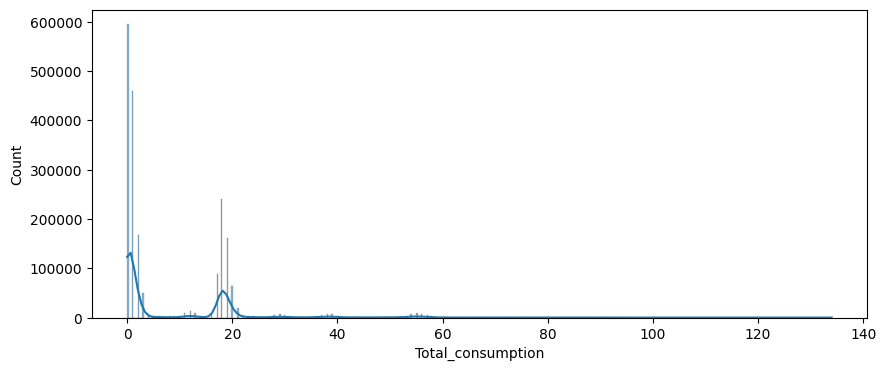

In [19]:
plt.figure(figsize=(10, 4))
sns.histplot(data= df, x= "Total_consumption", kde= True);

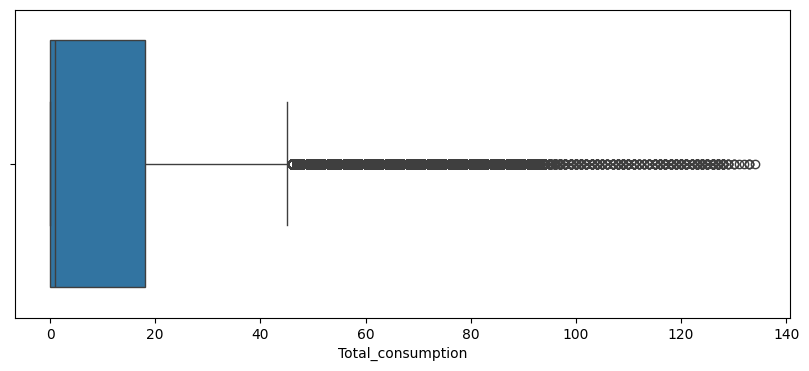

In [20]:
plt.figure(figsize=(10, 4))
sns.boxplot(data = df, x = 'Total_consumption');

In [21]:
year_totalConsumption= df.groupby('Year')['Total_consumption'].sum()

In [23]:
year_totalConsumption

,Total_consumption
Year,
2006,239123.0
2007,4519748.0
2008,4425876.0
2009,4741618.0
2010,4268968.0


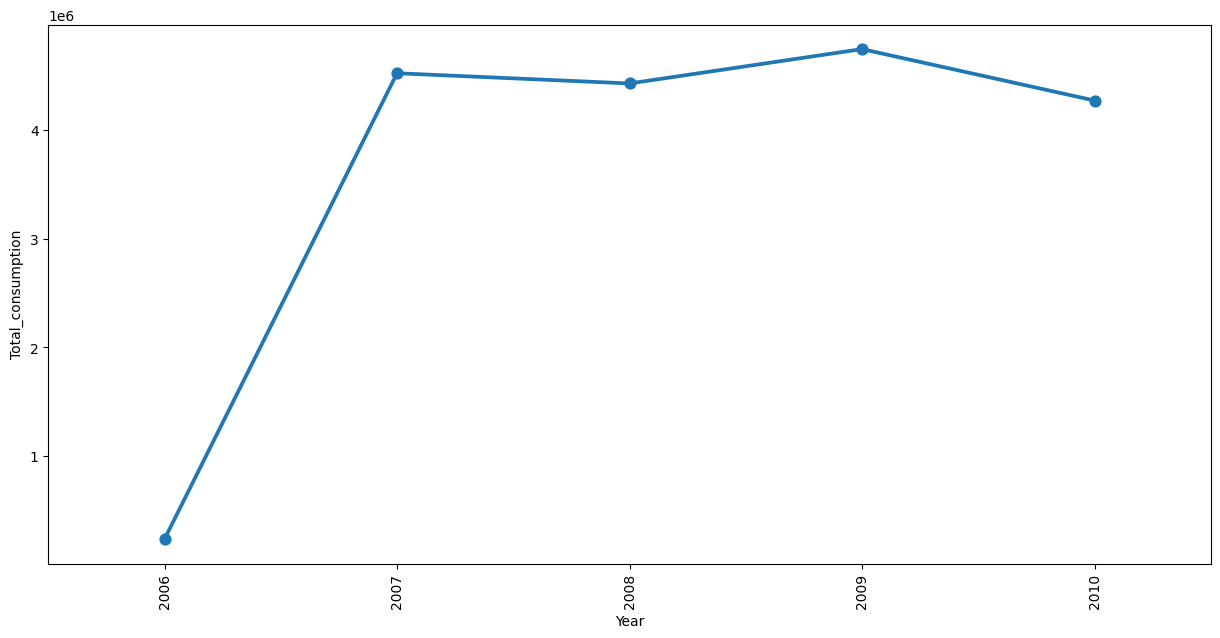

In [22]:
plt.figure(figsize=(15, 7))
sns.pointplot(x='Year', y='Total_consumption', data=df, estimator=sum, errorbar=None)
plt.xticks(rotation=90);
# TODO: December2026 data handling

In [40]:
df_2006 =df[(df['Year'] ==2006)]
df_2006.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Month,Day,Year,Total_consumption
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,12,16,2006,18.0
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,12,16,2006,17.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,12,16,2006,19.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,12,16,2006,18.0
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,12,16,2006,18.0


In [24]:
df_2007 =df[(df['Year'] ==2007)]
df_2007.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Month,Day,Year,Total_consumption
21996,2007-01-01,00:00:00,2.580,0.136,241.97,10.6,0.0,0.0,0.0,1,1,2007,0.0
21997,2007-01-01,00:01:00,2.552,0.100,241.75,10.4,0.0,0.0,0.0,1,1,2007,0.0
21998,2007-01-01,00:02:00,2.550,0.100,241.64,10.4,0.0,0.0,0.0,1,1,2007,0.0
21999,2007-01-01,00:03:00,2.550,0.100,241.71,10.4,0.0,0.0,0.0,1,1,2007,0.0
22000,2007-01-01,00:04:00,2.554,0.100,241.98,10.4,0.0,0.0,0.0,1,1,2007,0.0


In [25]:
df_2008 =df[(df['Year'] ==2008)]
df_2008.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Month,Day,Year,Total_consumption
547596,2008-01-01,00:00:00,1.620,0.070,241.25,6.6,0.0,0.0,18.0,1,1,2008,18.0
547597,2008-01-01,00:01:00,1.626,0.072,241.74,6.6,0.0,0.0,18.0,1,1,2008,18.0
547598,2008-01-01,00:02:00,1.622,0.072,241.52,6.6,0.0,0.0,18.0,1,1,2008,18.0
547599,2008-01-01,00:03:00,1.612,0.070,240.82,6.6,0.0,0.0,18.0,1,1,2008,18.0
547600,2008-01-01,00:04:00,1.612,0.070,240.80,6.6,0.0,0.0,18.0,1,1,2008,18.0


In [26]:
df_2009 =df[(df['Year'] ==2009)]
df_2009.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Month,Day,Year,Total_consumption
1074636,2009-01-01,00:00:00,0.484,0.062,247.86,2.2,0.0,0.0,0.0,1,1,2009,0.0
1074637,2009-01-01,00:01:00,0.484,0.062,247.72,2.2,0.0,0.0,0.0,1,1,2009,0.0
1074638,2009-01-01,00:02:00,0.482,0.062,247.75,2.2,0.0,0.0,0.0,1,1,2009,0.0
1074639,2009-01-01,00:03:00,0.482,0.060,247.52,2.2,0.0,0.0,0.0,1,1,2009,0.0
1074640,2009-01-01,00:04:00,0.482,0.062,246.94,2.2,0.0,0.0,0.0,1,1,2009,0.0


In [27]:
df_2010 =df[(df['Year'] ==2010)]
df_2010.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Month,Day,Year,Total_consumption
1600236,2010-01-01,00:00:00,1.790,0.236,240.65,7.4,0.0,0.0,18.0,1,1,2010,18.0
1600237,2010-01-01,00:01:00,1.780,0.234,240.07,7.4,0.0,0.0,18.0,1,1,2010,18.0
1600238,2010-01-01,00:02:00,1.780,0.234,240.15,7.4,0.0,0.0,19.0,1,1,2010,19.0
1600239,2010-01-01,00:03:00,1.746,0.186,240.26,7.2,0.0,0.0,18.0,1,1,2010,18.0
1600240,2010-01-01,00:04:00,1.686,0.102,240.12,7.0,0.0,0.0,18.0,1,1,2010,18.0


Text(0.5, 1.0, '2010')

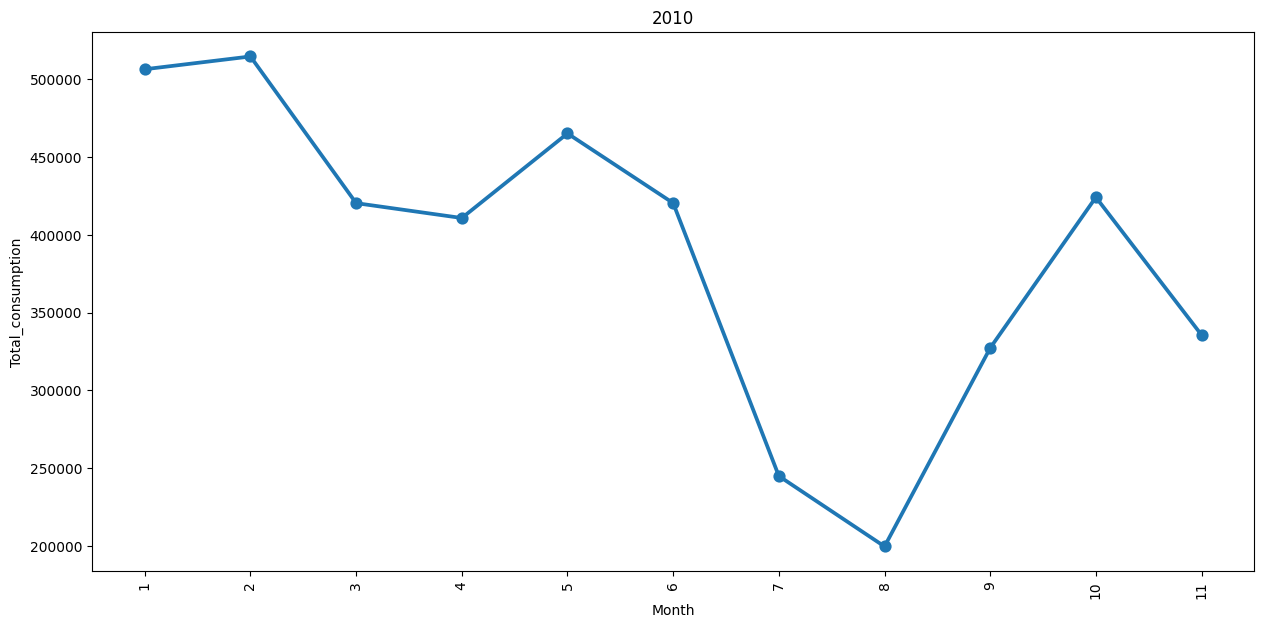

In [28]:
plt.figure(figsize=(15, 7))
sns.pointplot(x='Month', y='Total_consumption', data=df_2010, estimator=sum, errorbar=None)
plt.xticks(rotation=90);
plt.title('2010')

Text(0.5, 1.0, '2009')

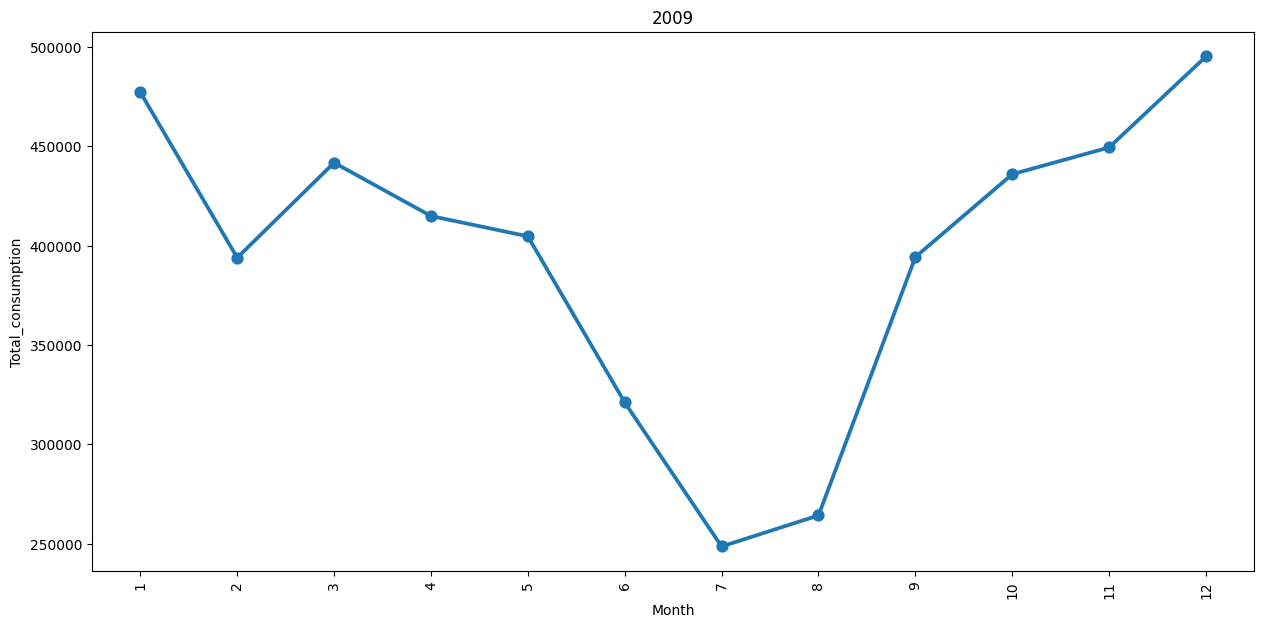

In [29]:
plt.figure(figsize=(15, 7))
sns.pointplot(x='Month', y='Total_consumption', data=df_2009, estimator=sum, errorbar=None)
plt.xticks(rotation=90);
plt.title('2009')

Text(0.5, 1.0, '2008')

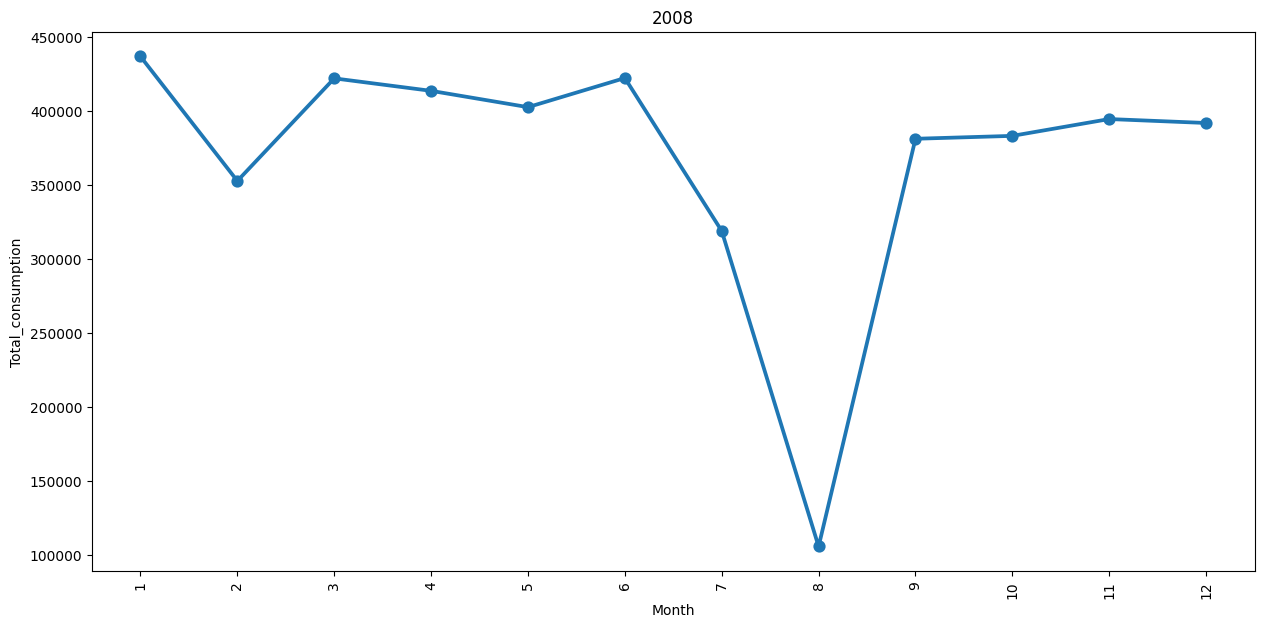

In [30]:
plt.figure(figsize=(15, 7))
sns.pointplot(x='Month', y='Total_consumption', data=df_2008, estimator=sum, errorbar=None)
plt.xticks(rotation=90);
plt.title('2008')

Text(0.5, 1.0, '2007')

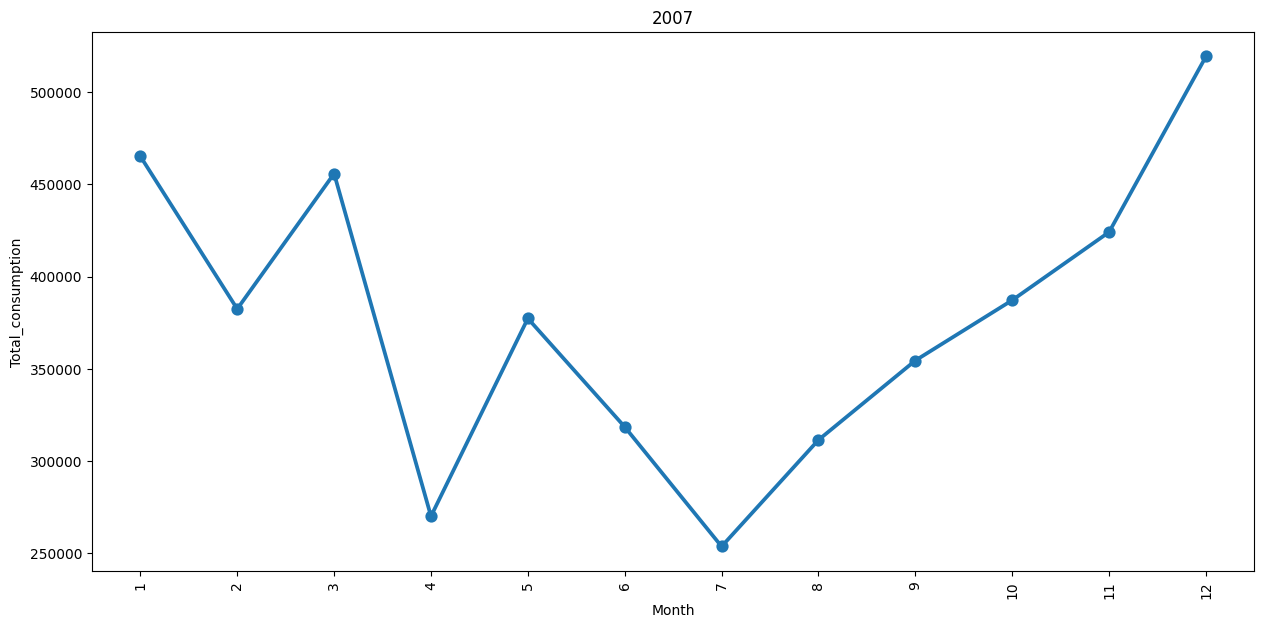

In [31]:
plt.figure(figsize=(15, 7))
sns.pointplot(x='Month', y='Total_consumption', data=df_2007, estimator=sum, errorbar=None)
plt.xticks(rotation=90);
plt.title('2007')

Text(0.5, 1.0, '2006')

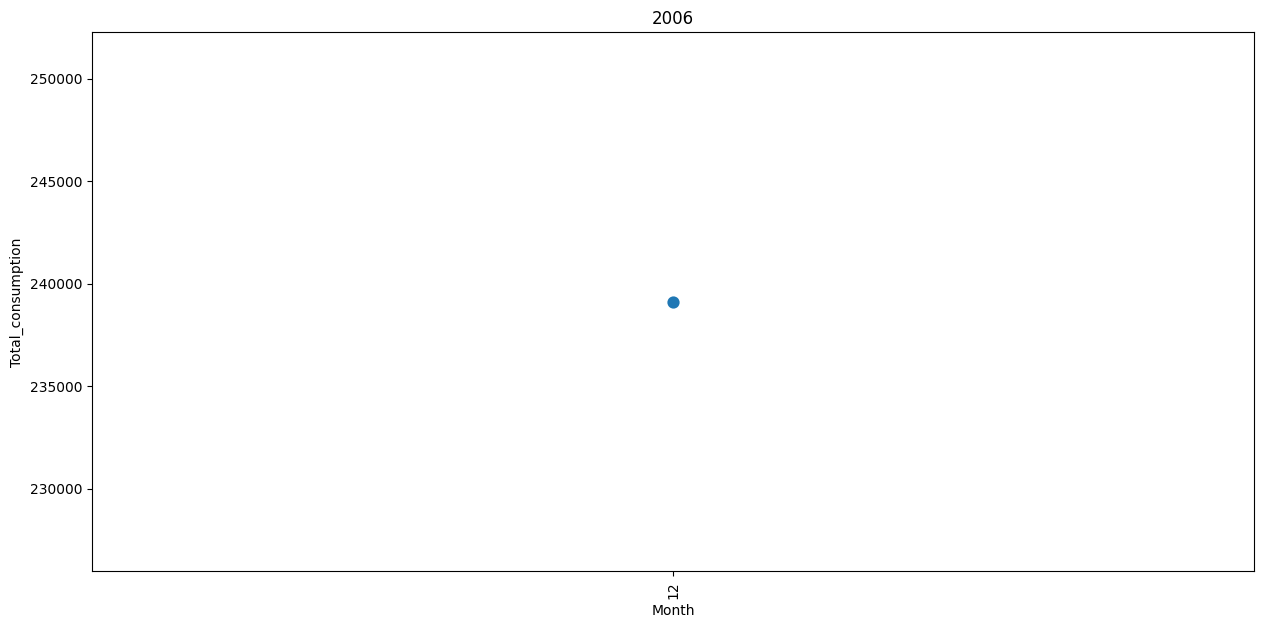

In [32]:
plt.figure(figsize=(15, 7))
sns.pointplot(x='Month', y='Total_consumption', data=df_2006, estimator=sum, errorbar=None)
plt.xticks(rotation=90);
plt.title('2006')

TODO: Plot x axit month, 4 lines for different years
TODO: 1 Plot for all month and all years

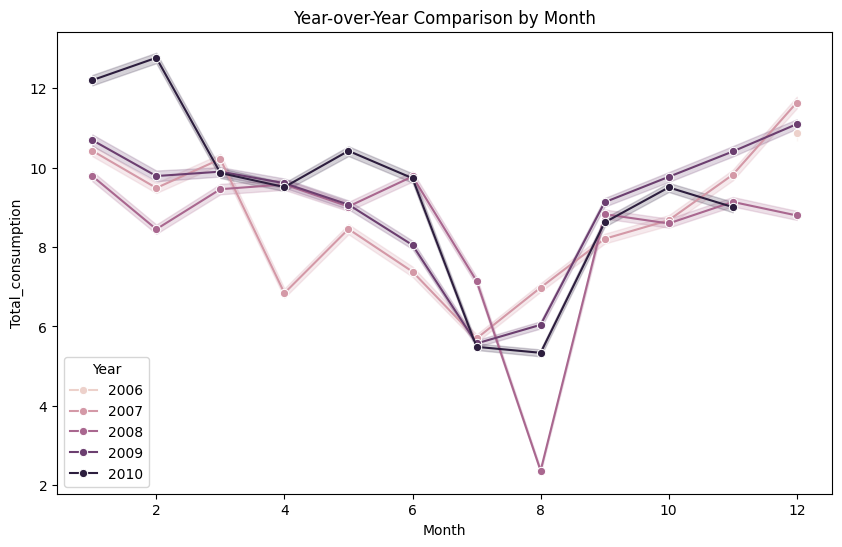

In [41]:
# 2. Plot with years as separate lines
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Month', y='Total_consumption', hue='Year', marker='o')
plt.title('Year-over-Year Comparison by Month')
plt.show()

In [44]:
df_Total_consumption = df['Total_consumption'];

In [45]:
# Select every 30th row (starting from index 0)
every_th_row = df_Total_consumption.iloc[::30]

# Sum across rows for each column
sum_every_30th = every_30th_row.sum()

print("Every 30th row:\n", every_30th_row)
print("\nSum of every 30th row:\n", sum_every_30th)

NameError: name 'every_30th_row' is not defined

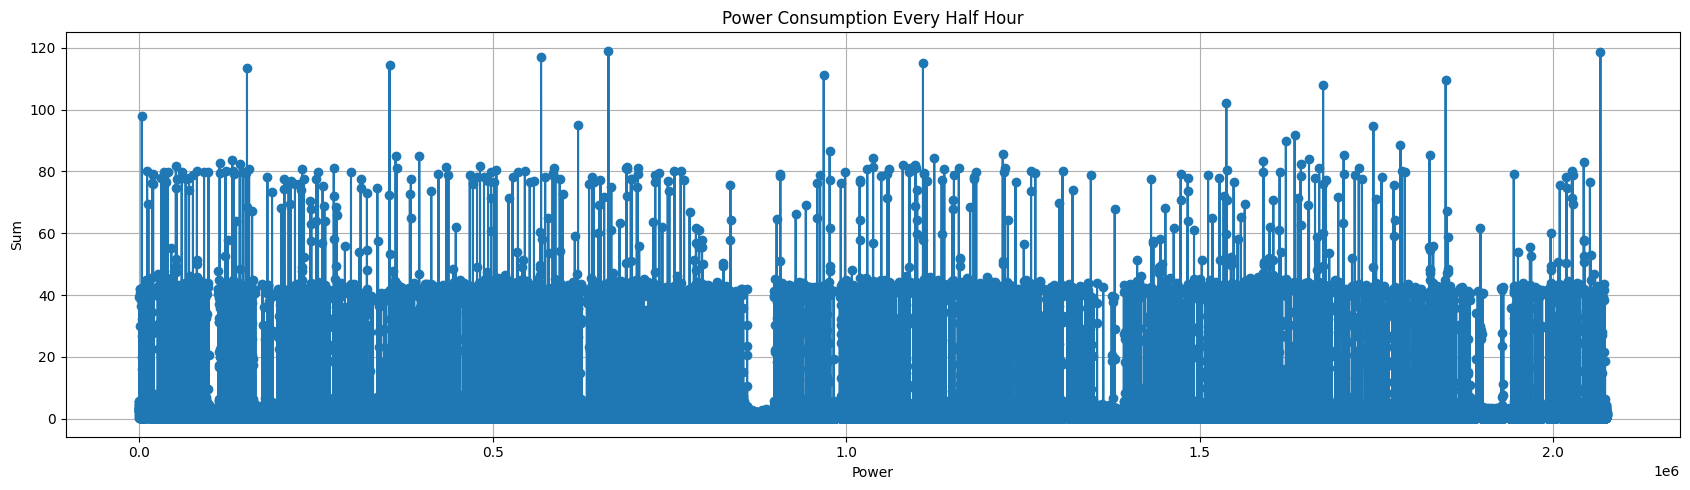

In [ ]:
# Plot the summed values
plt.figure(figsize=(17, 5))
plt.plot(every_30th_row, marker='o', linestyle='-')
plt.title('Power Consumption Every Half Hour')
plt.xlabel('Power')
plt.ylabel('Sum')
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
df['Date_Time'] = df['Date'].dt.strftime('%Y-%m-%d') + " " + df['Time'].astype(str)
df['Date_Time'] = pd.to_datetime(df['Date_Time'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 14 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   datetime64[ns]
 1   Time                   object        
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   Month                  int32         
 10  Day                    int32         
 11  Year                   int32         
 12  Total_consumption      float64       
 13  Date_Time              datetime64[ns]
dtypes: datetime64[ns](2), float64(8), int32(3), object(1)
memory usage: 197.9+ MB


In [ ]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Month,Day,Year,Total_consumption,Date_Time
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,12,16,2006,5.216,2006-12-16 17:24:00
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,12,16,2006,6.360,2006-12-16 17:25:00
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,12,16,2006,7.374,2006-12-16 17:26:00
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,12,16,2006,6.388,2006-12-16 17:27:00
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,12,16,2006,4.666,2006-12-16 17:28:00


In [47]:
df_date=df.groupby([df['Date_Time'].dt.date]).Total_consumption.sum()

In [48]:
df_date.head()

,Total_consumption
Date_Time,
2006-12-16,5472.0
2006-12-17,19561.0
2006-12-18,17702.0
2006-12-19,14638.0
2006-12-20,16711.0


In [ ]:
df_date.tail()

,Total_consumption
Date_Time,
2010-11-22,9006.536
2010-11-23,3906.536
2010-11-24,5740.248
2010-11-25,2933.164
2010-11-26,2953.104


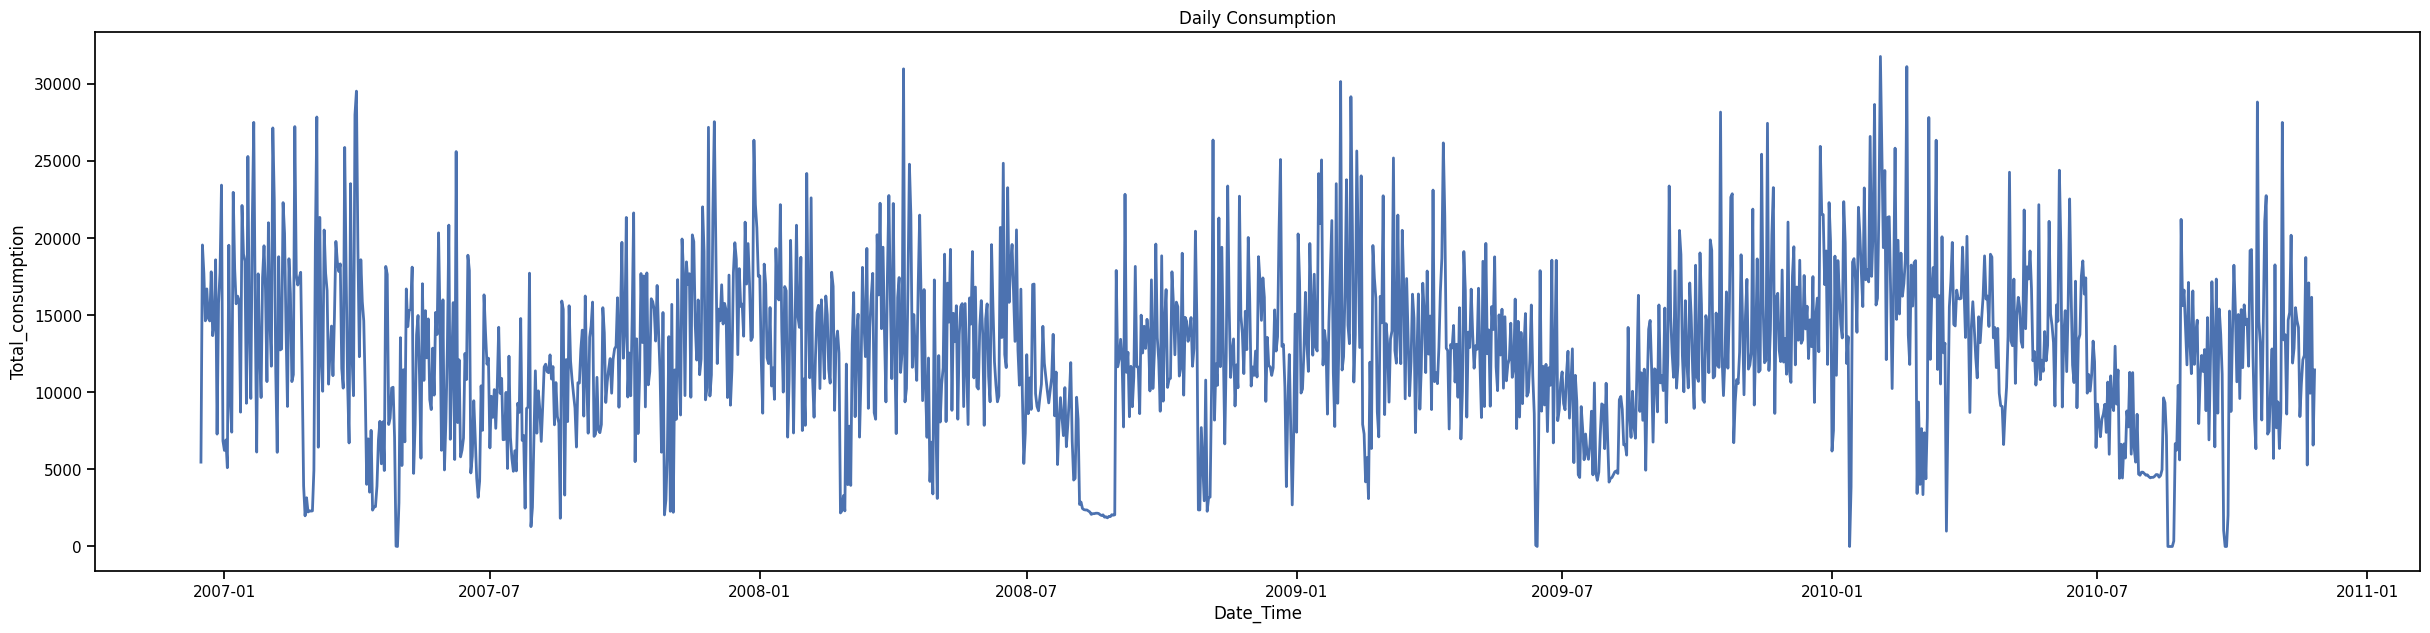

In [49]:
plt.figure(figsize=(30, 7))
sns.set_theme(style=None)
sns.lineplot( data=df_date, linewidth=2);
plt.title("Daily Consumption");

In [ ]:
df_month=df.groupby([df['Date_Time'].dt.month]).Total_consumption.sum()

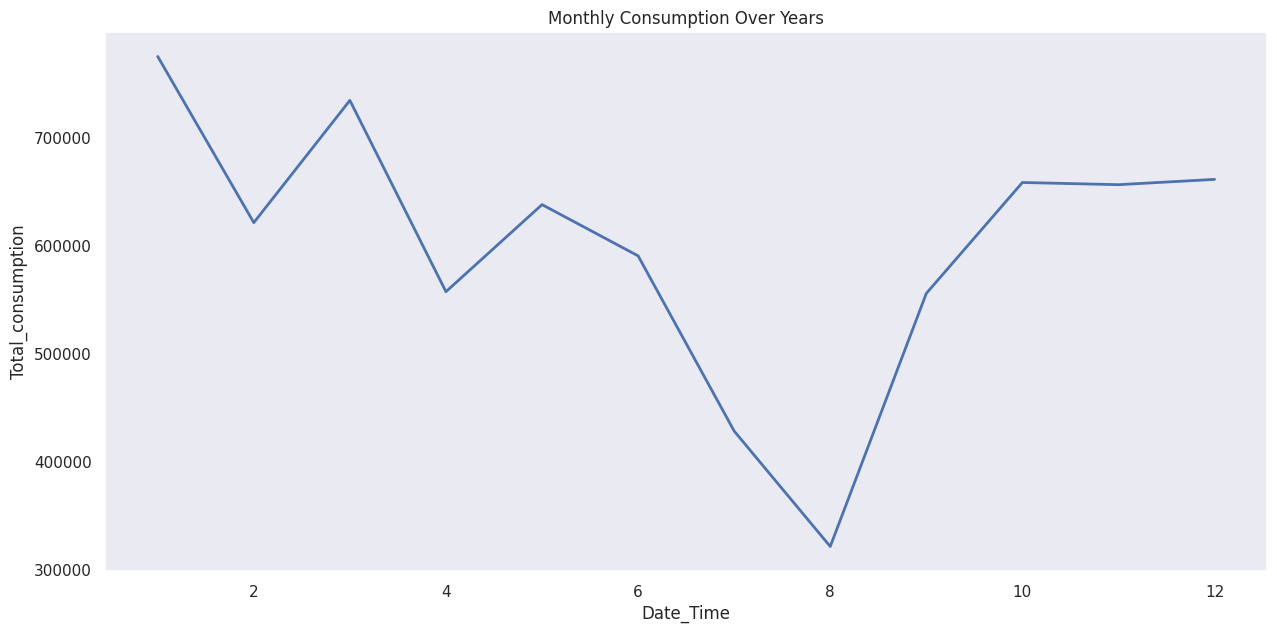

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot( data=df_month,   linewidth=2);
plt.title("Monthly Consumption Over Years");

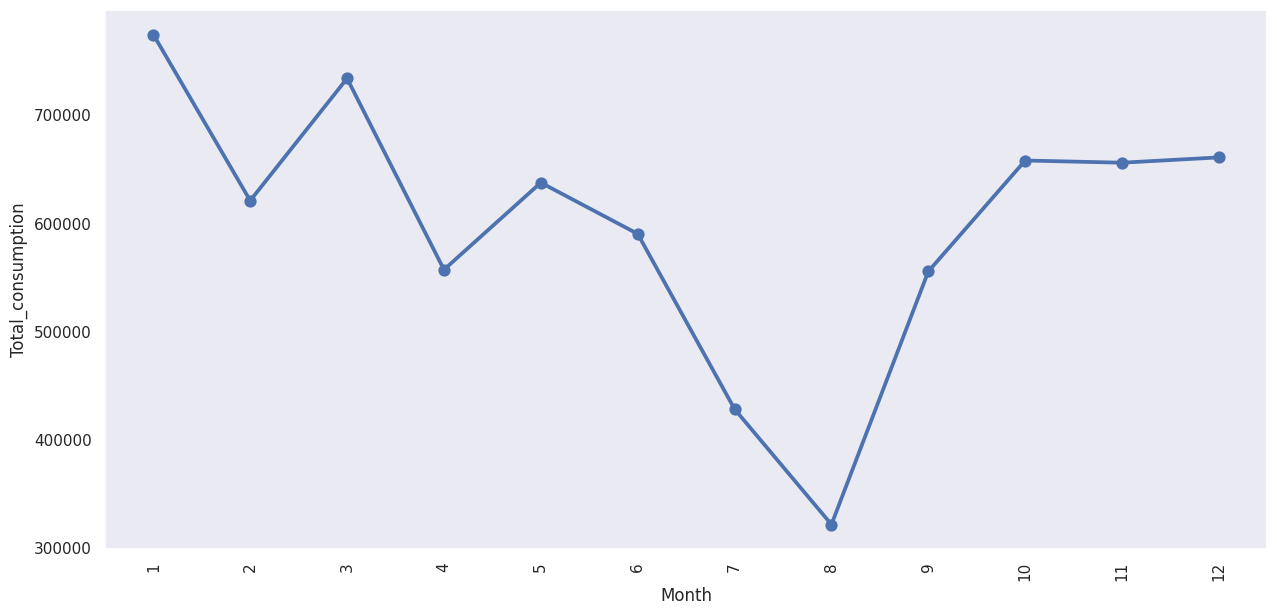

In [ ]:
plt.figure(figsize=(15, 7))
sns.pointplot(x='Month', y='Total_consumption', data=df, estimator=sum, errorbar=None)
plt.xticks(rotation=90);

In [ ]:
month_totalConsumption= df.groupby('Month')['Total_consumption'].sum().reset_index()

<Figure size 2000x600 with 0 Axes>

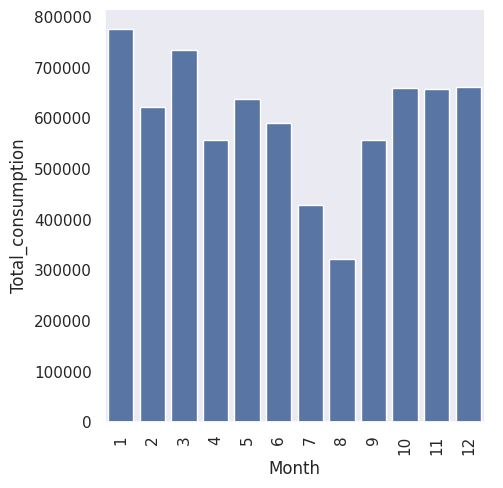

In [ ]:
plt.figure(figsize=(20,6));
sns.catplot(data=month_totalConsumption,x= 'Month', y='Total_consumption', kind='bar');
plt.xticks(rotation=90);

In [ ]:
month_totalConsumption

,Total_consumption
Month,
1,774947.910
2,621179.754
3,734318.670
4,557270.106
5,637844.962
6,590427.204
7,428253.444
8,321439.118
9,555681.386


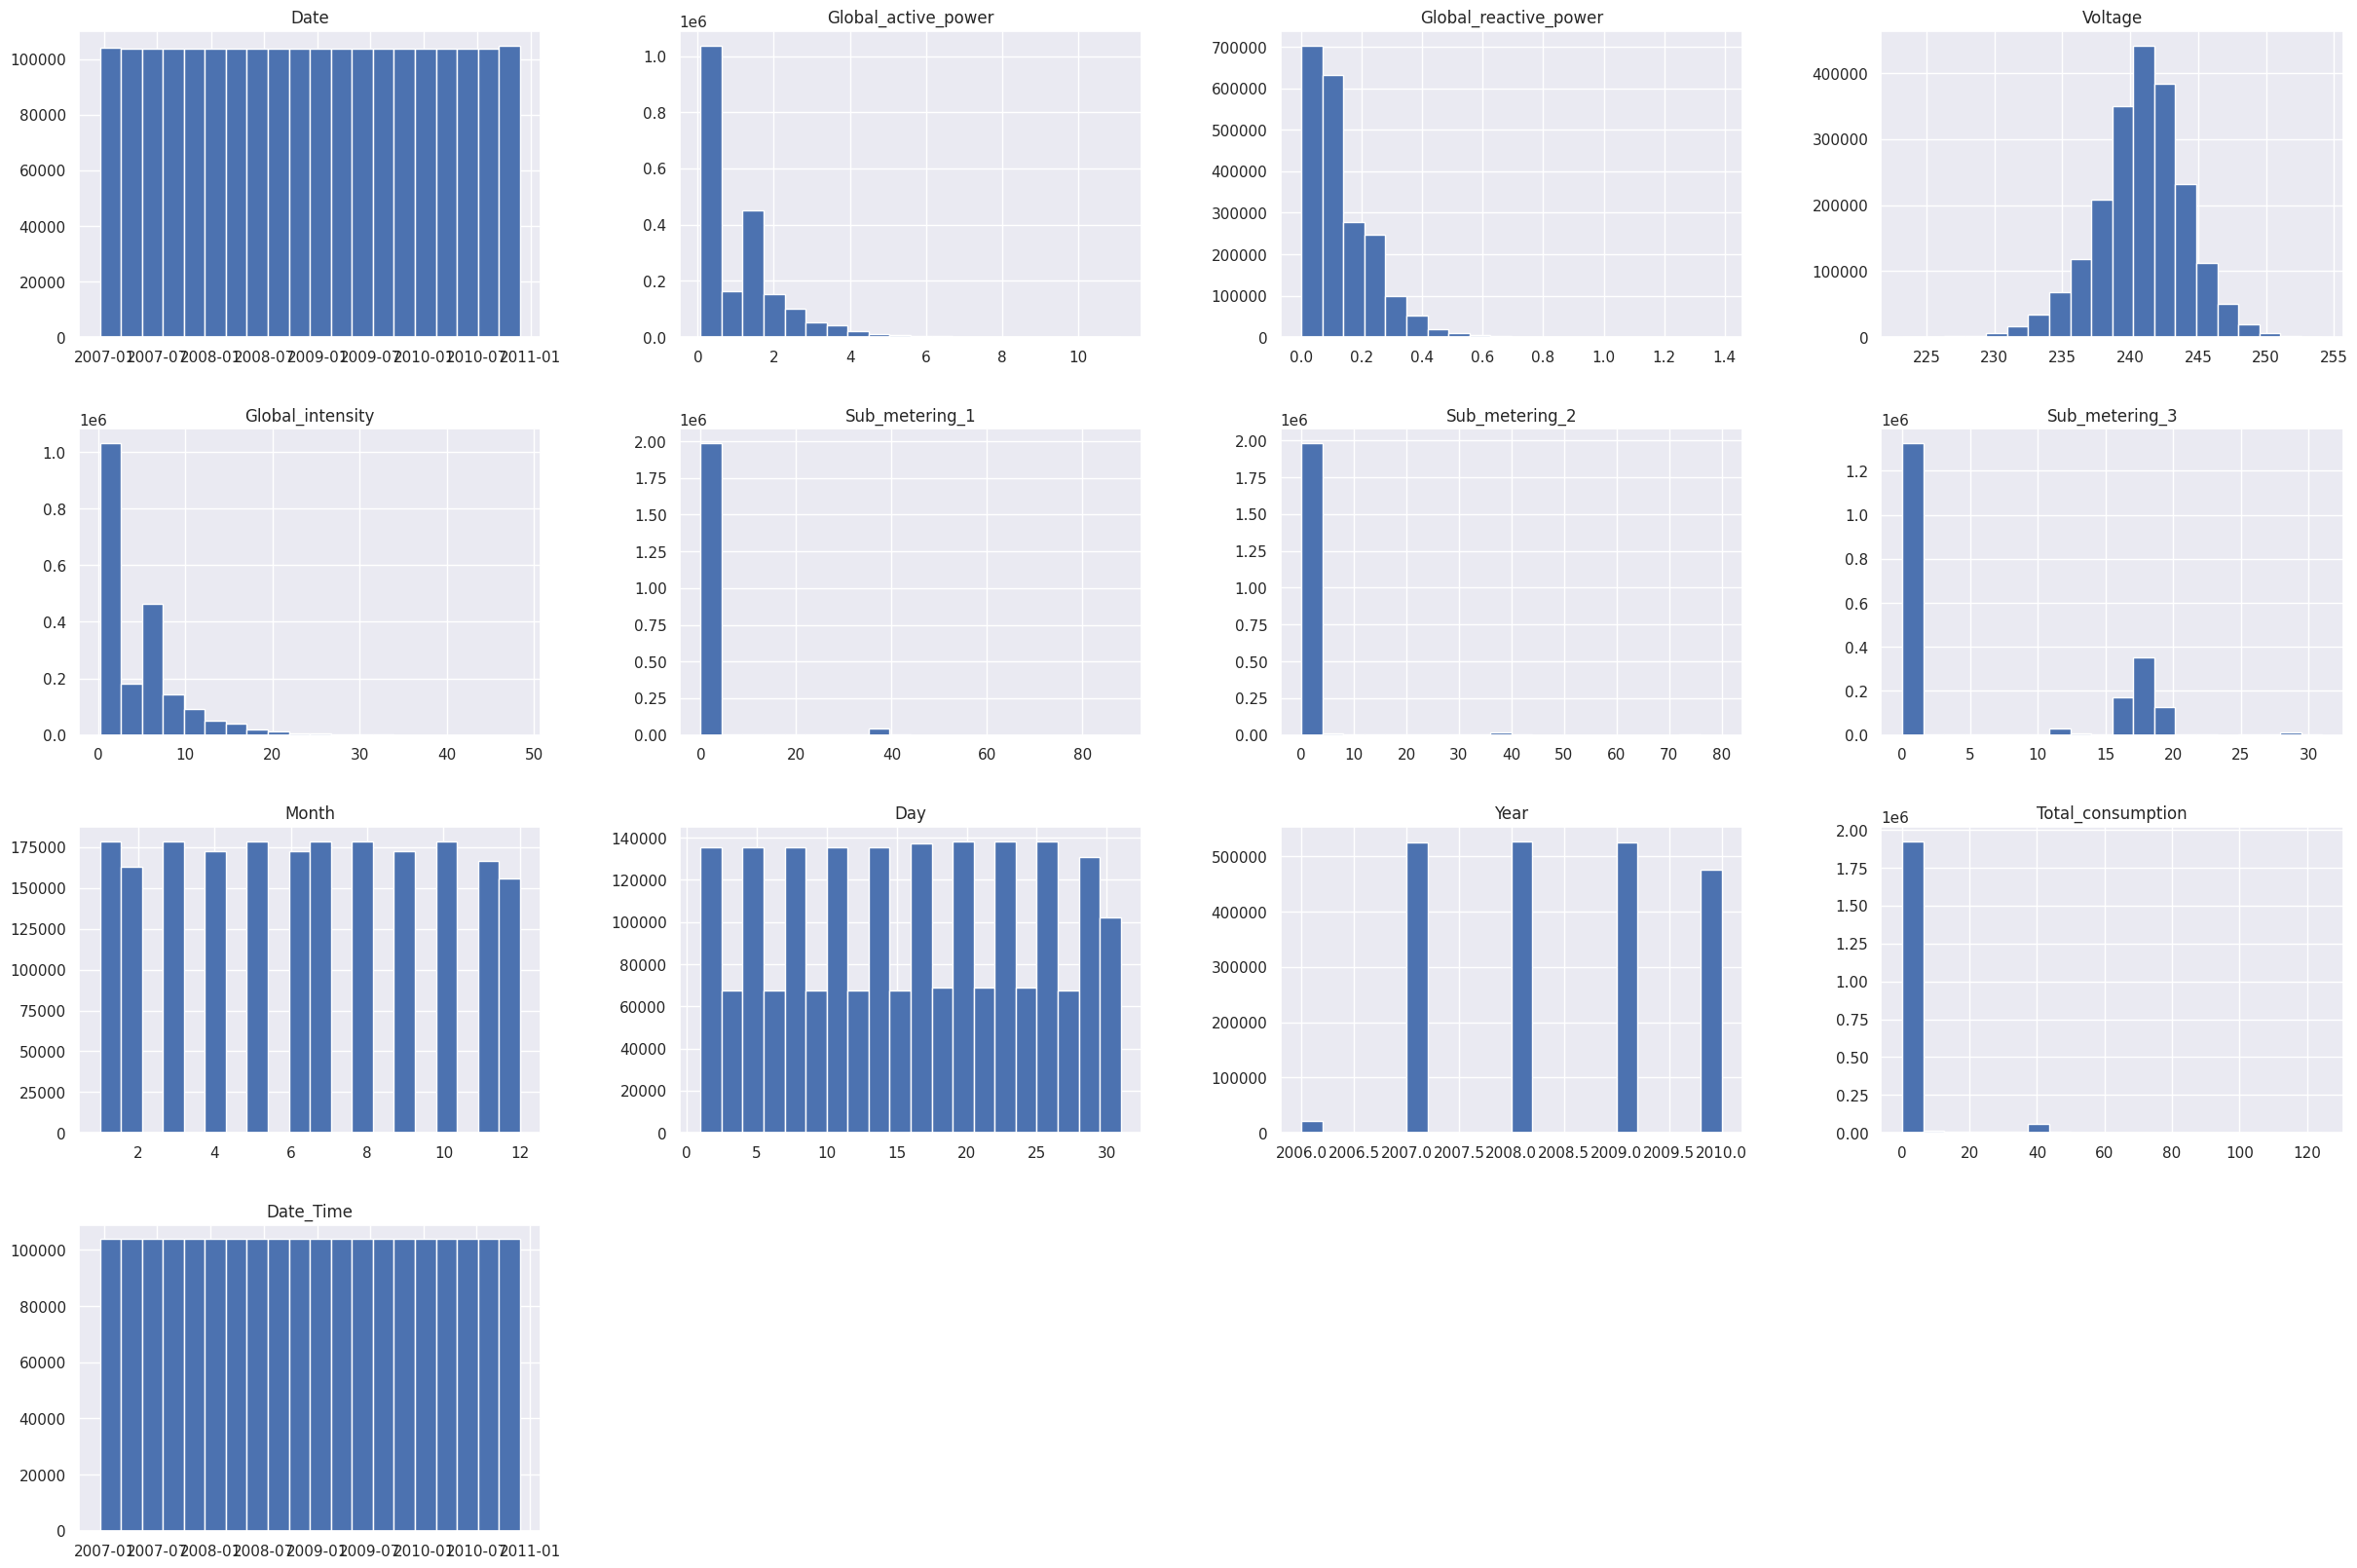

In [ ]:

df.hist(bins=20, figsize=(30,20))
plt.show()

Bi-Variate Analysis

<Figure size 2000x700 with 0 Axes>

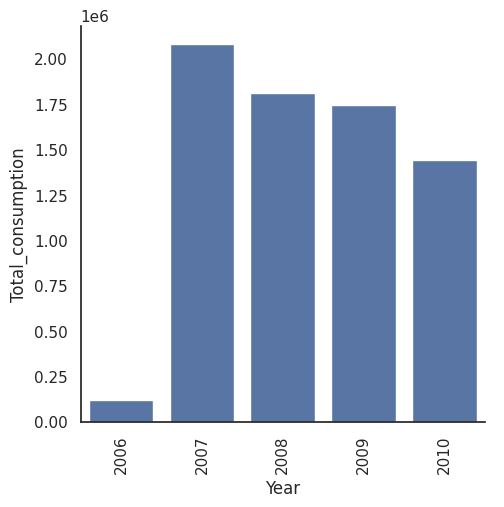

In [ ]:
plt.figure(figsize=(20,7));
sns.catplot(data=year_totalConsumption.reset_index(),x= 'Year', y='Total_consumption', kind='bar');
plt.xticks(rotation=90);

<Figure size 2000x700 with 0 Axes>

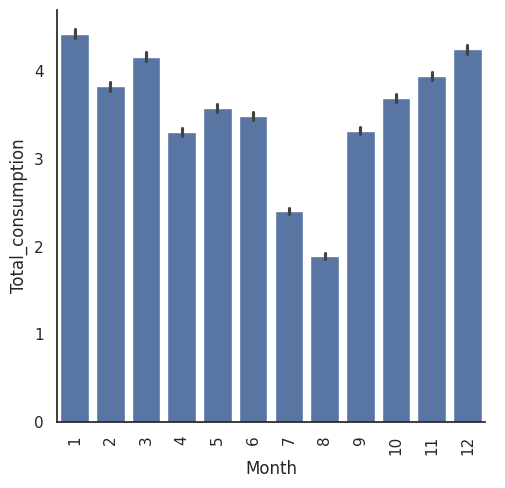

In [ ]:
plt.figure(figsize=(20,7));
sns.catplot(data=df,x= 'Month', y='Total_consumption', kind='bar');
plt.xticks(rotation=90);

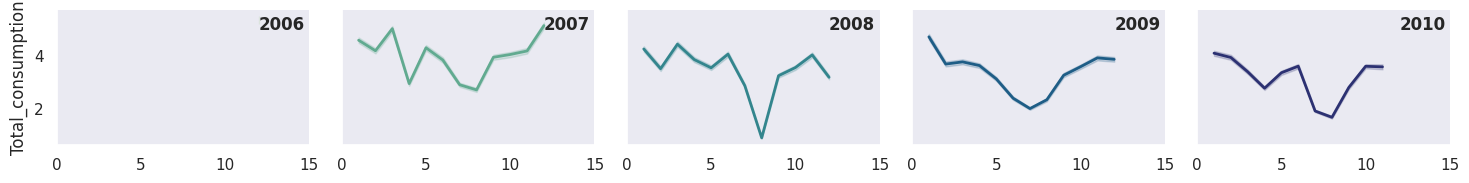

In [ ]:
sns.set_theme(style="dark")

# Plot each year's time series in its own facet
g = sns.relplot(
    data=df,
    x="Month", y="Total_consumption", col="Year", hue="Year",
    kind="line", palette="crest", linewidth=2, zorder=5,
    col_wrap=5, height=2, aspect=1.5, legend=False,
)

# Iterate over each subplot to customize further
for year, ax in g.axes_dict.items():

    # Add the title as an annotation within the plot
    ax.text(.8, .85, year, transform=ax.transAxes, fontweight="bold")

# Reduce the frequency of the x axis ticks
ax.set_xticks(ax.get_xticks()[::2])

# Tweak the supporting aspects of the plot
g.set_titles("")
g.set_axis_labels("", "Total_consumption")
g.tight_layout();

Multi-Variate Analysis

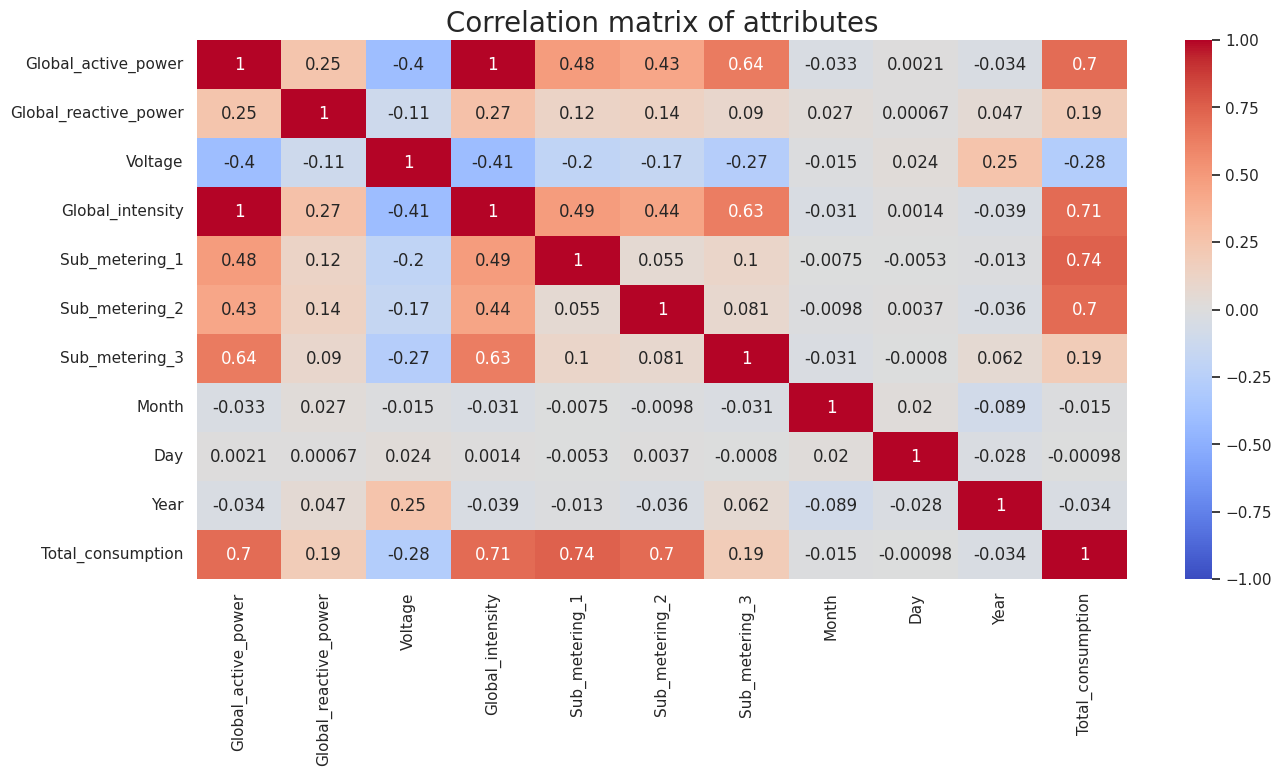

In [ ]:
corr_matrix = df.corr(numeric_only=True)

sns.set(style='white')
plt.figure(figsize=(15, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix of attributes', fontsize=20)
plt.show()

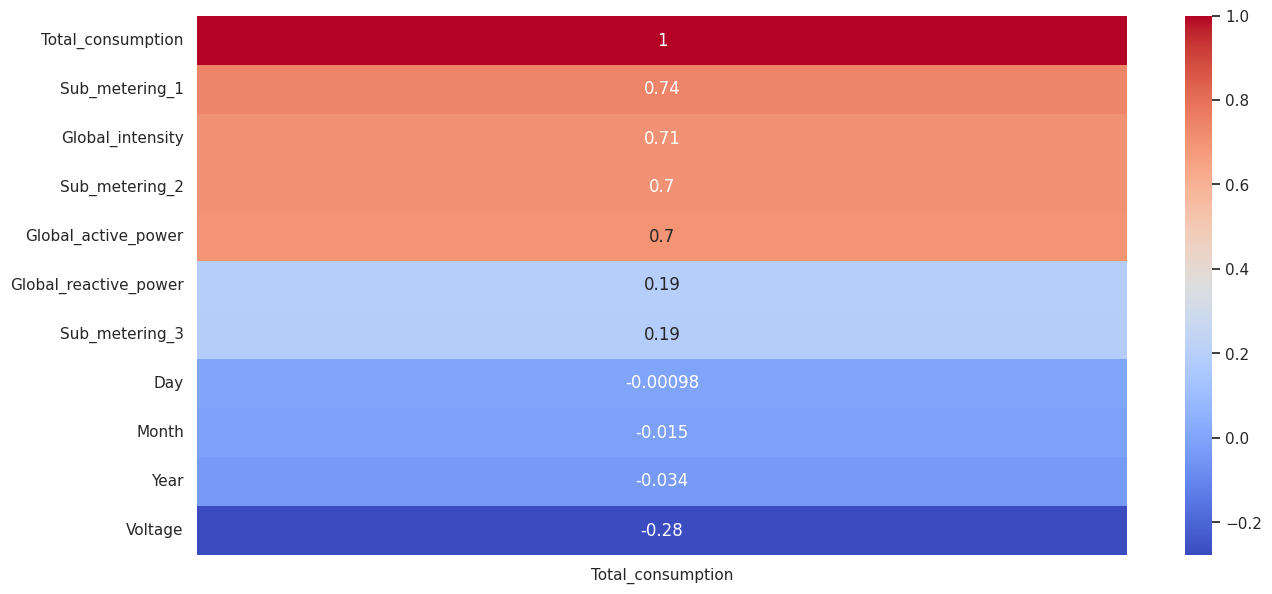

In [ ]:
cm = corr_matrix[['Total_consumption']].sort_values(by='Total_consumption', ascending=False)
plt.figure(figsize=(15,7))
sns.heatmap(cm, cmap='coolwarm', annot=True)
plt.show()

In [ ]:
cm

,Total_consumption
Total_consumption,1.000000
Sub_metering_1,0.742590
Global_intensity,0.705025
Sub_metering_2,0.703717
Global_active_power,0.698370
Global_reactive_power,0.194509
Sub_metering_3,0.188961
Day,-0.000981
Month,-0.014630
Year,-0.034323
